In [19]:
import pandas as pd
import numpy as np
import seaborn as sns                       
import matplotlib.pyplot as plt             

In [20]:
df = pd.read_csv("Cars Company.csv")
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


#### 1. Check and Drop Duplicate Records

In [21]:
df.shape

(11914, 16)

In [22]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11909    False
11910    False
11911    False
11912    False
11913    False
Length: 11914, dtype: bool

In [23]:
df.drop_duplicates()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


#### 2. Check and Drop missing or null values

In [24]:

df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [25]:
df = df.dropna()    # Dropping the missing values.
df.count()

Make                 8084
Model                8084
Year                 8084
Engine Fuel Type     8084
Engine HP            8084
Engine Cylinders     8084
Transmission Type    8084
Driven_Wheels        8084
Number of Doors      8084
Market Category      8084
Vehicle Size         8084
Vehicle Style        8084
highway MPG          8084
city mpg             8084
Popularity           8084
MSRP                 8084
dtype: int64

In [26]:
print(df.isnull().sum())

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64


#### 3. What are the top 10 average MSRP (Price) per car brand (rounded figure)? with Horizontal Bar Plot

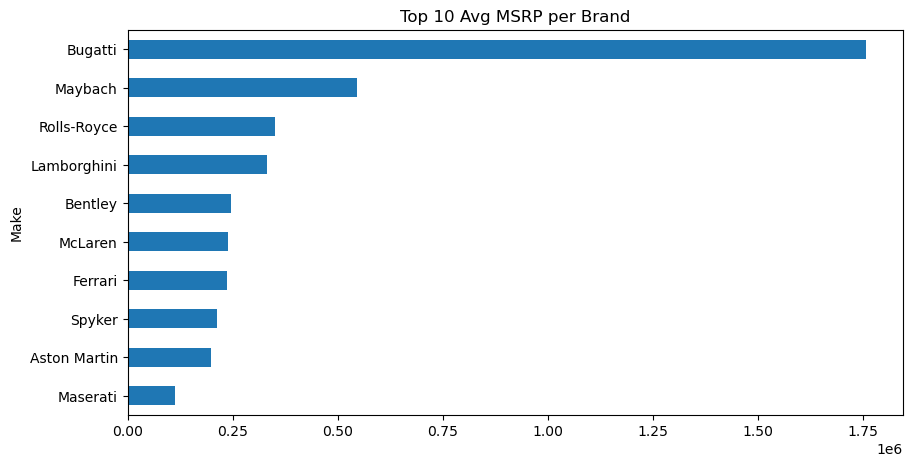

In [27]:
avg_msrp = df.groupby('Make')['MSRP'].mean().round().sort_values(ascending=False).head(10)
avg_msrp.plot(kind='barh', figsize=(10,5), title='Top 10 Avg MSRP per Brand'); plt.gca().invert_yaxis(); plt.show()


#### 4. How has the MSRP (price) changed over the years (rounded figure)? with Line Plot

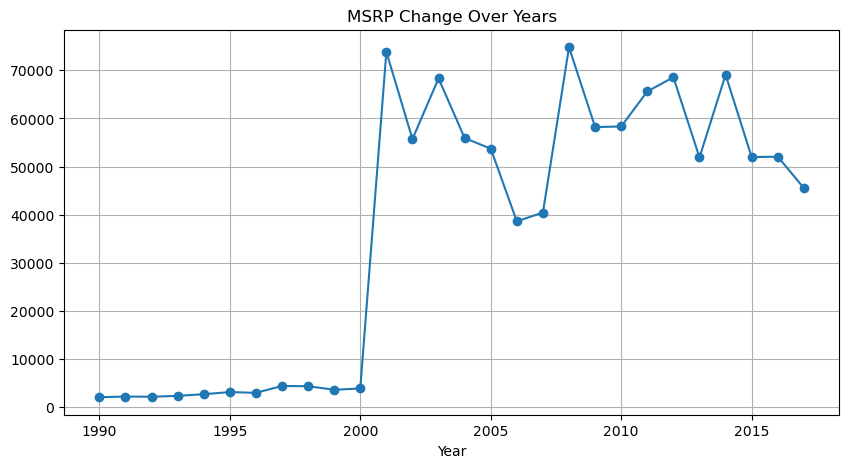

In [31]:
msrp_by_year = df.groupby('Year')['MSRP'].mean().round()
msrp_by_year.plot(kind='line', marker='o', title='MSRP Change Over Years', figsize=(10,5)); plt.grid(); plt.show()


#### 5. How Engine HP (power) and MPG (efficiency) have changed over the years? show with two line plots

Hint: Average of (city mpg + highway MPG)

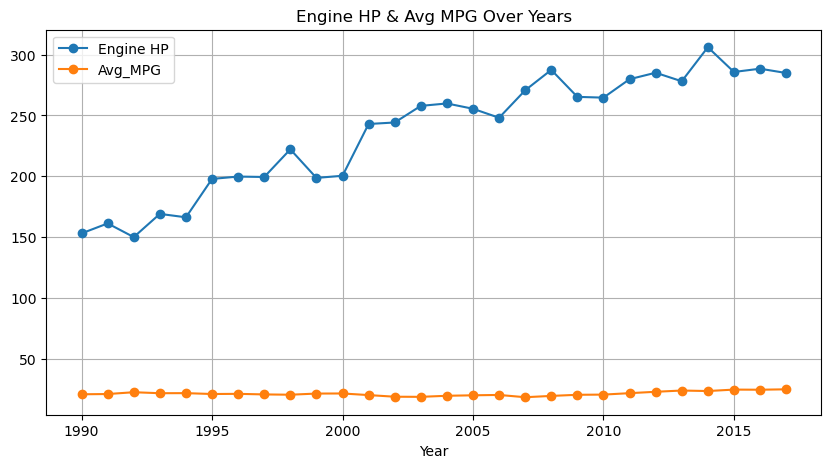

In [33]:
df.loc[:, 'Avg_MPG'] = (df['city mpg'] + df['highway MPG']) / 2
df.groupby('Year')[['Engine HP', 'Avg_MPG']].mean().plot(title='Engine HP & Avg MPG Over Years', figsize=(10,5), marker='o'); plt.grid(); plt.show()


# : is used to target all rows..

#### 6. What percentage of cars are Compact, Midsize, or Large? Show with Pie chart

Text(0, 0.5, '')

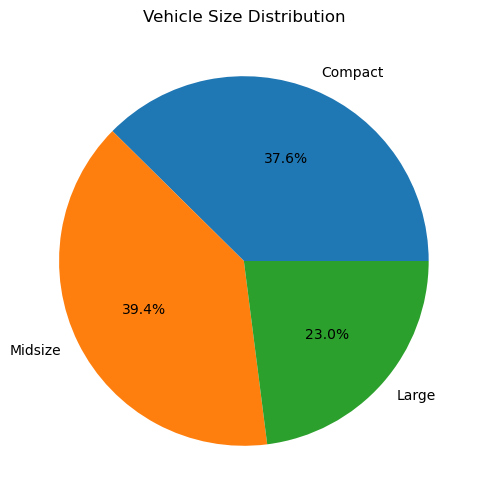

In [34]:
size_counts = df['Vehicle Size'].value_counts(normalize=True).loc[['Compact', 'Midsize', 'Large']] * 100
size_counts.plot.pie(autopct='%1.1f%%', title='Vehicle Size Distribution', figsize=(6,6)); plt.ylabel('')



#### 7. Which vehicle styles are sold the most? show with vertical bar plot

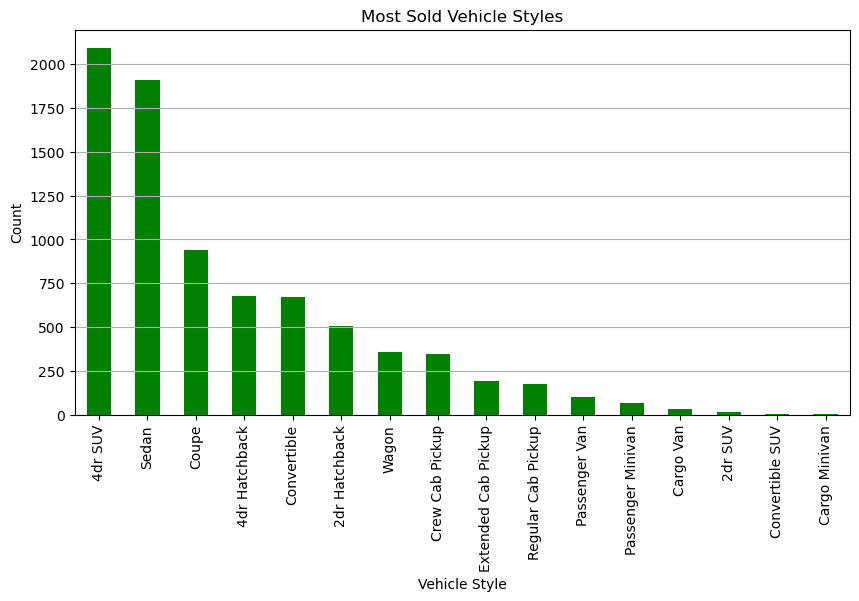

In [39]:
style_counts = df['Vehicle Style'].value_counts()
style_counts.plot(kind='bar', figsize=(10,5), title='Most Sold Vehicle Styles', color='green'); plt.ylabel('Count'); plt.grid(axis='y')


#### 8. Which car brands have the most vehicles priced at $40,000 or more and with a popularity score of at least 1000?

In [36]:
filtered = df[(df['MSRP'] >= 40000) & (df['Popularity'] >= 1000)]
filtered['Make'].value_counts()


Make
Cadillac       354
BMW            276
Audi           224
Chevrolet      171
Porsche        123
Ford           105
Nissan          69
Ferrari         68
Toyota          55
Lamborghini     52
Dodge           52
Kia             16
Hyundai         13
Chrysler        12
Honda            8
Name: count, dtype: int64